# 01. Diabetes Health Indicators: Exploratory Data Analysis & Preprocessing

**Objective:** To perform an initial assessment of the BRFSS 2015 dataset, investigate key health indicators, and establish a statistically sound preprocessing pipeline for diabetes risk prediction.

### 1. Data Loading and Initial Inspection

We begin by loading the dataset to understand its dimensions, data types, and check for any missing values.

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("muted")

def load_diabetes_data(data_path='datasets/diabetes_012_health_indicators_BRFSS2015.csv'):
    file_path = Path(data_path)
    if not file_path.is_file():
        raise FileNotFoundError('Dataset not found. Please download it manually from Kaggle and place it in the datasets folder.')
    return pd.read_csv(file_path)

diabetes_data = load_diabetes_data()

In [78]:
pd.set_option('display.max_columns', None)
diabetes_data.head()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [79]:
diabetes_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

In [80]:
diabetes_data.describe()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.296921,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,0.811420,0.056197,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.698160,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,0.391175,0.230302,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,2.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


**Interpretation 1: Initial Data Structure**

1. **Data Integrity:** Out of more than 250,000 records, there is not a single missing value. This is an exceptionally clean state for real-world medical data.
2. **Data Types:** All features are currently parsed as `float64`. Categorical variables such as `Sex` or `HighBP` will require appropriate encoding in the subsequent preprocessing pipeline to prevent the model from misinterpreting them as continuous variables.

### 2. Target Variable Analysis (The Premise for Splitting)
Before splitting the data, we must examine the distribution of our target variable (`Diabetes_012`) to determine the appropriate sampling strategy.

In [83]:
# Check target distribution on the full dataset
target_dist = diabetes_data['Diabetes_012'].value_counts(normalize=True).round(3) * 100
print('Target Distribution (%):\n', target_dist)

Target Distribution (%):
 Diabetes_012
0.0    84.2
2.0    13.9
1.0     1.8
Name: proportion, dtype: float64


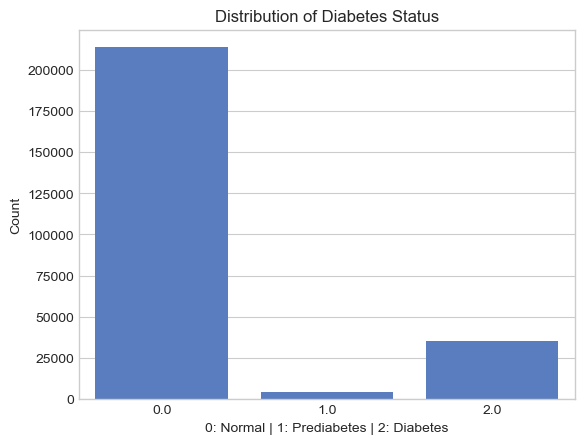

In [84]:
sns.countplot(x='Diabetes_012', data=diabetes_data)
plt.title('Distribution of Diabetes Status')
plt.xlabel('0: Normal | 1: Prediabetes | 2: Diabetes')
plt.ylabel('Count')
plt.show()

**Interpretation 2: Discovery of Class Imbalance**

* **Observation:** The dataset is heavily skewed. The 'Normal' group accounts for approximately 84.2% of the data, while 'Prediabetes' is dangerously underrepresented at just 1.8%.
* **Strategic Decision:** A standard random split would risk creating a test set that misrepresents the minority classes. Therefore, we must use a **Stratified Split** to ensure the train and test sets maintain this exact proportion.

### 3. Data Cleaning and Stratified Split
Based on our findings, we first remove exact duplicates to prevent data leakage, and then apply the stratified split.  
*Note: From this point forward, the Test set will be locked away. All further EDA will be conducted solely on the Training set to prevent data snooping bias.*

In [87]:
dup_count = diabetes_data.duplicated().sum()
print('Number of duplicate rows:', dup_count)

Number of duplicate rows: 23899


In [88]:
# Extract all rows that are exact duplicates (including all occurrences)
duplicates = diabetes_data[diabetes_data.duplicated(keep=False)]
# Sort and show first 5 duplicates
duplicates.sort_values(list(diabetes_data.columns)).head()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
4517,0.0,0.0,0.0,0.0,17.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,8.0,6.0,8.0
207307,0.0,0.0,0.0,0.0,17.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,8.0,6.0,8.0
42369,0.0,0.0,0.0,0.0,18.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,10.0,6.0,8.0
108949,0.0,0.0,0.0,0.0,18.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,10.0,6.0,8.0
17475,0.0,0.0,0.0,0.0,19.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,4.0,6.0,8.0


The duplicated records were inspected to understand their nature.
However, due to the absence of a unique identifier and the structure of the dataset, it is not possible to definitively determine whether these rows represent true data duplication or coincidental identical observations.

Given that these records do not add additional information for modeling and may introduce unnecessary redundancy, they will be removed as part of the data cleaning process.

In [90]:
diabetes_data = diabetes_data.drop_duplicates()

In [ ]:
# Separate features and target
